Enable autoreload so edits to `src/*.py` are picked up automatically without restarting the kernel - otherwise, after editing e.g. `src/experiment.py`, the already-running kernel keeps using the old version of its functions, and calls like `save_results(...)` fail with a `TypeError` about the number of arguments.

In [1]:
%load_ext autoreload
%autoreload 2

Imports: standard library, torch/torchvision, and the project's shared modules (`src/*`).

In [2]:
import json
import ssl

import torch
from torch import nn, optim
from torch.utils.data import random_split, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet

from src.dataset import define_transformations
from src.experiment import prepare_results_dir, save_results, save_model, save_config, save_classes
from src.metrics import plot_training_metrics
from src.training import training_loop

ssl._create_default_https_context = ssl._create_unverified_context
from torchvision.models import MobileNet_V3_Large_Weights, mobilenet_v3_large

Using device: MPS (Apple Silicon GPU)


Pick the training device: CUDA -> MPS (Apple Silicon) -> CPU.

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


Load hyperparameters from `configs/base_config.json`.

In [4]:
with open("../configs/base_config.json", encoding="utf-8") as file:
    config_json = json.load(file)

seed = int(config_json["seed"])

batch_size = int(config_json["data"]["batch_size"])
augmentation = config_json["data"]["augmentation"]

model = config_json["model"]["name"]
dropout = config_json["model"]["dropout"]
UNFREEZE_FROM_BLOCK = int(config_json["model"]["unfreeze_from_block"])

learning_rate = float(config_json["training"]["learning_rate"])
weight_decay = float(config_json["training"]["weight_decay"])
label_smoothing = float(config_json["training"]["label_smoothing"])
scheduler_config = config_json["training"]["scheduler"]
epochs = int(config_json["training"]["epochs"])

early_stopping_config = config_json["training"]["early_stopping"]
early_stopping_patience = int(early_stopping_config["patience"])
early_stopping_min_delta = float(early_stopping_config["min_delta"])

Build the train/val transform pipelines and load the Oxford-IIIT Pet dataset. `train_dataset` and `val_dataset` are two SEPARATE instances (one per transform) so validation images get the deterministic `val_transform`, not the random training augmentation.

In [5]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_transform, val_transform = define_transformations(augmentation, IMAGENET_MEAN, IMAGENET_STD)
train_dataset = OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)
val_dataset = OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=True,
    transform=val_transform
)

Split trainval into train/val (70/30) using shared indices, and build the DataLoaders.

In [6]:
generator = torch.Generator().manual_seed(seed)
train_indices, val_indices = random_split(train_dataset, [0.7, 0.3], generator=generator)

train_loader = DataLoader(Subset(train_dataset, train_indices.indices), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(Subset(val_dataset, val_indices.indices), batch_size=batch_size, shuffle=False)

Number of classes (breeds) in the dataset.

In [7]:
num_classes = len(train_dataset.classes)
print(f"{num_classes} classes found.")

37 classes found.


Load MobileNetV3-Large with pretrained ImageNet weights.

In [8]:
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
model = mobilenet_v3_large(weights=weights)

Inspect the full model structure.

In [9]:
model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kern

Inspect the classifier head specifically.

In [10]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)


Inspect the final classifier layer (the one we'll resize to `num_classes`).

In [11]:
model.classifier[3]

Linear(in_features=1280, out_features=1000, bias=True)

Freeze the whole backbone, then unfreeze the last few blocks (`UNFREEZE_FROM_BLOCK`) and the classifier head for fine-tuning; resize the classifier's dropout and final layer to this dataset.

In [12]:
for param in model.parameters():
    param.requires_grad = False

for block in model.features[UNFREEZE_FROM_BLOCK:]:
    for param in block.parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model.classifier[2] = nn.Dropout(p=dropout)  # before - 0.2
model.classifier[3] = nn.Linear(
    in_features=model.classifier[3].in_features,
    out_features=num_classes,
)

Move the model to the training device.

In [13]:
model = model.to(device)

Optimizer with discriminative learning rates (lower LR + higher weight decay for the pretrained backbone, full LR for the new head), loss with label smoothing, and the LR scheduler.

In [14]:
backbone_params = [p for b in model.features[UNFREEZE_FROM_BLOCK:] for p in b.parameters()]
head_params = list(model.classifier.parameters())

optimizer = optim.Adam([
    {"params": backbone_params, "lr": learning_rate / 10, "weight_decay": weight_decay * 3},
    {"params": head_params, "lr": learning_rate, "weight_decay": weight_decay},
])

loss_function = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=scheduler_config["mode"],
    factor=float(scheduler_config["factor"]),
    patience=int(scheduler_config["patience"]),
    min_lr=float(scheduler_config["min_lr"]),
)

Keep BatchNorm layers in the still-frozen backbone blocks in eval() even after `model.train()` is called elsewhere - otherwise their running statistics keep drifting away from the pretrained ImageNet values.

In [15]:
def freeze_bn_in_frozen_blocks(model, unfreeze_from):
    trainable_ids = {id(m) for b in model.features[unfreeze_from:] for m in b.modules()}
    trainable_ids |= {id(m) for m in model.classifier.modules()}
    original_train = model.train

    def train_override(mode=True):
        original_train(mode)
        if mode:
            for module in model.modules():
                if isinstance(module, nn.BatchNorm2d) and id(module) not in trainable_ids:
                    module.eval()
        return model

    model.train = train_override
    return model

Apply the BatchNorm freeze to the model.

In [16]:
model = freeze_bn_in_frozen_blocks(model, UNFREEZE_FROM_BLOCK)

Sanity check: confirm the loss function's label smoothing value.

In [17]:
loss_function.label_smoothing

0.1

Allocate a new `experiments/<N>` directory for this run.

In [18]:
results_dir, exp_number, exp_path = prepare_results_dir("../experiments")
print("Results Directory:", results_dir)
print("Experiment Number:", exp_number)
print("Experiment Path:", exp_path)

Results Directory: ../experiments
Experiment Number: 46
Experiment Path: ../experiments/46


Save this run's config into its experiment directory (`config.json`).

In [19]:
save_config(exp_path, config_json)

Run training (stops early on its own if early stopping triggers).

In [20]:
trained_model, training_metrics = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=epochs,
    device=device,
    scheduler=scheduler,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)

--- Training Started ---
Epoch [1/50], Train Loss: 2.5179, Train Accuracy: 51.94% Val Loss: 1.2066, Val Accuracy: 86.05%
Epoch [2/50], Train Loss: 1.3404, Train Accuracy: 80.16% Val Loss: 1.0865, Val Accuracy: 89.40%
Epoch [3/50], Train Loss: 1.2131, Train Accuracy: 84.98% Val Loss: 1.0301, Val Accuracy: 90.31%
Epoch [4/50], Train Loss: 1.1777, Train Accuracy: 84.78% Val Loss: 1.0195, Val Accuracy: 91.03%
Epoch [5/50], Train Loss: 1.1209, Train Accuracy: 87.77% Val Loss: 1.0183, Val Accuracy: 90.76%
Epoch [6/50], Train Loss: 1.1047, Train Accuracy: 87.85% Val Loss: 1.0005, Val Accuracy: 91.49%
Epoch [7/50], Train Loss: 1.0708, Train Accuracy: 88.94% Val Loss: 0.9875, Val Accuracy: 91.49%
Epoch [8/50], Train Loss: 1.0554, Train Accuracy: 90.26% Val Loss: 0.9782, Val Accuracy: 91.58%
Epoch [9/50], Train Loss: 1.0455, Train Accuracy: 90.72% Val Loss: 0.9837, Val Accuracy: 90.85%
Epoch [10/50], Train Loss: 1.0331, Train Accuracy: 90.33% Val Loss: 0.9749, Val Accuracy: 92.12%
Epoch [11/50],

Plot and save the train/val loss and accuracy curves (`results.png`).


--- Training Plots ---



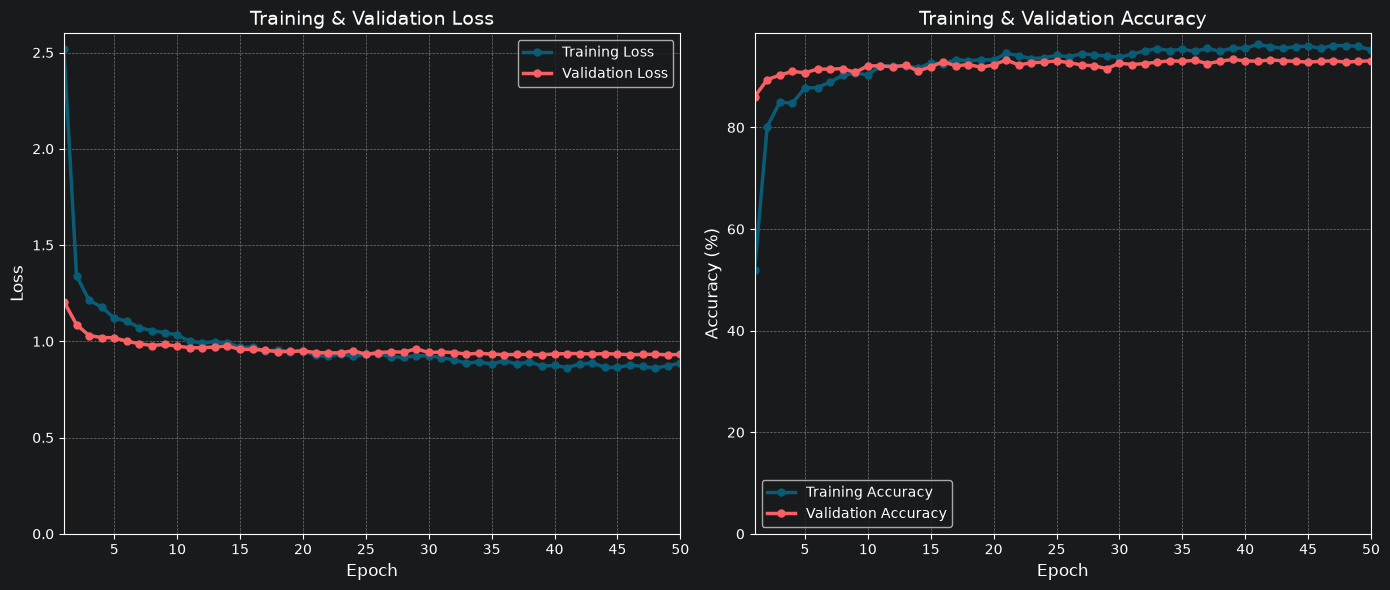

In [21]:
print("\n--- Training Plots ---\n")
plot_training_metrics(training_metrics, exp_path)

Append this run's results to `experiments/summary.csv` and `metrics.csv`.

In [22]:
save_results(results_dir,
             exp_path,
             exp_number,
             learning_rate,
             training_metrics,
             model.__class__.__name__,
             len(training_metrics[0]),
             batch_size,
             optimizer.__class__.__name__,
             weight_decay,
             seed,
             str(augmentation),
             dropout,
             scheduler_config,
             label_smoothing,
             UNFREEZE_FROM_BLOCK
             )

Save the trained model's weights (`model.pt`).

In [23]:
save_model(exp_path, model)

Save the index -> breed-name mapping (`classes.json`) alongside the checkpoint, for inference later.

In [24]:
save_classes(exp_path, train_dataset.classes)